In [2]:
!pip -q install ucimlrepo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
from re import X
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [5]:
y = y.iloc[:, 0]
y = (y > 0).astype(int)

print("Missing values:")
print(X.isnull().sum())

print("\nTarget distribution:")
print(y.value_counts())

print("\nDataset shape:")
print(X.shape)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Target distribution:
num
0    164
1    139
Name: count, dtype: int64

Dataset shape:
(303, 13)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 242
Testing samples: 61


In [7]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
random_forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])
logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)
print("Both models trained successfully.")

Both models trained successfully.


In [8]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}
results = []
for name, model in models.items():
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:, 1]

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, zero_division=0)
  recall = recall_score(y_test, y_pred, zero_division=0)
  f1 = f1_score(y_test, y_pred, zero_division=0)
  roc_auc = roc_auc_score(y_test, y_prob)

  results.append({
      "Model": name,
      "Accuracy": accuracy,
      "Precision": precision,
      "Recall": recall,
      "F1 Score": f1,
      "ROC-AUC": roc_auc
  })
  results_df = pd.DataFrame(results)
  display(results_df.round(4))
  

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Random Forest,0.9016,0.8438,0.9643,0.9000,0.9545


f
{name}
[[27  6]
 [ 2 26]]


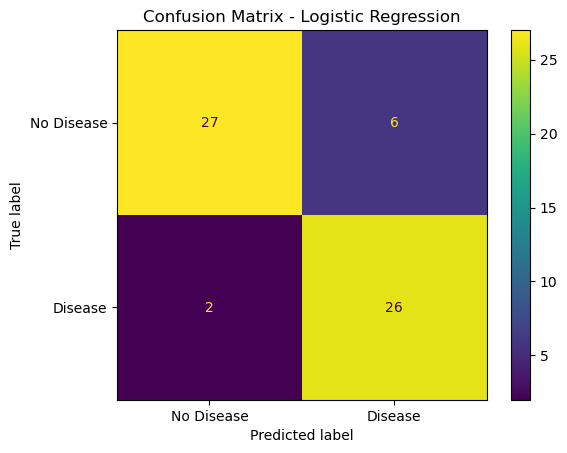

f
{name}
[[28  5]
 [ 1 27]]


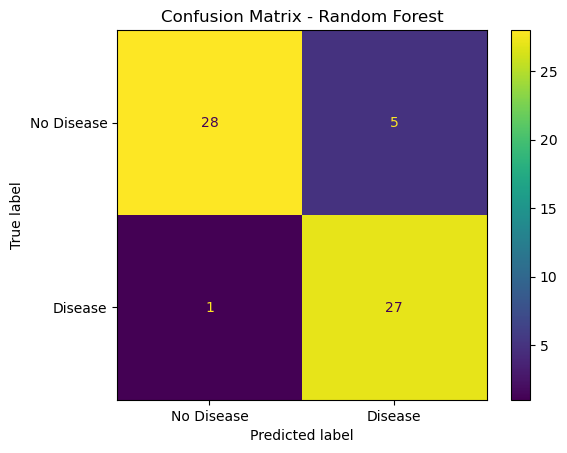

In [9]:
for name, model in models.items():
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  print("f\n{name}")
  print(cm)
  ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=["No Disease", "Disease"]
  ).plot()
  plt.title(f"Confusion Matrix - {name}")
  plt.show()

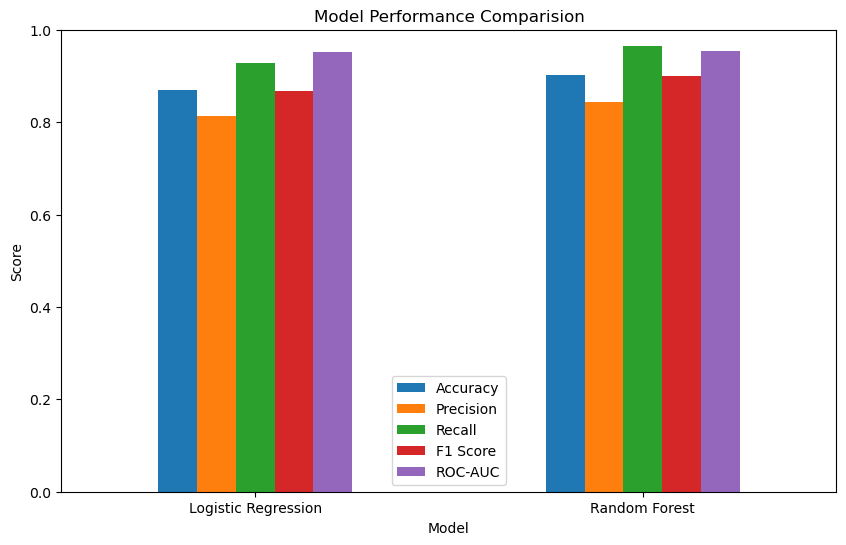

In [10]:
results_plot = results_df.set_index("Model")
results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparision")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [11]:
# Findings
# The experiment compared Logistic Regression and Random Forest for binary heart disease prediction using the UCI Heart Disease dataset. Both models were trained using the same training and testing data and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The evaluation results show how the two models differ in their ability to classify patients with and without heart disease. The confusion matrices also provide information about correct and incorrect predictions for each class. With more time, I would perform additional cross-validation, hyperparameter tuning, and testing on larger and more diverse datasets. I would also investigate feature importance and model interpretability to better understand which clinical variables contribute to predictions.